# GOLDMAN SACHS FINANCIAL RISK ANALYSIS

## Imported different python libraries to perform tasks mentioned.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import zscore
from matplotlib.patches import Patch
from scipy.stats import ttest_ind
from statsmodels.stats.weightstats import ztest

## Loading Goldman Sachs Financial Transactional Dataset(csv format) from local system
### "df" used as variable for storing Goldman Sachs Data

In [ ]:
df = pd.read_csv(r"C:\Users\mohit\Desktop\Data Science Project\Python Project\goldman_sachs.csv")
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,33,CUST6549,ACC12334,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 1,21-10-2023,87480.05448,74008.43310,0.729101,319,200
1,177,CUST2942,ACC52650,Credit,Withdrawal,Home Loan,Firm A,East,Manager 3,20-06-2023,20315.74505,22715.83590,0.472424,692,47
2,178,CUST6776,ACC45101,Current,Deposit,Personal Loan,Firm C,South,Manager 3,02-01-2023,10484.57165,42706.09210,0.648784,543,109
3,173,CUST2539,ACC88252,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,25-07-2023,45122.27373,114176.56870,0.734832,430,103
4,67,CUST2626,ACC21878,Savings,Withdrawal,Home Loan,Firm C,Central,Manager 4,25-07-2023,42360.79878,17863.02644,0.289304,468,234


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


In [ ]:
df.describe()

,TransactionID,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,98.401250,51575.671765,72345.657910,0.473415,566.586250,126.58250
std,56.292618,29055.838886,34070.038539,0.242858,151.674261,68.98532
min,1.000000,-30721.247890,-37293.600250,-0.389354,305.000000,6.00000
25%,50.000000,31692.004800,49157.502723,0.313286,436.500000,65.00000
50%,97.000000,50249.069385,72789.370195,0.472155,563.000000,132.00000
75%,146.000000,71913.394570,95352.455698,0.636848,696.000000,186.25000
max,199.000000,130726.914100,175247.539500,1.163728,849.000000,239.00000


In [ ]:
df.isnull().sum()

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

# Task 1: Data Cleaning and Formatting

 ### Formatted date format using to_datetime function to convert date from Object data type to datetime65[ns] data type

In [ ]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"],errors="coerce")
df.head()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 468 to 510
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   TransactionID        800 non-null    int64         
 1   CustomerID           800 non-null    object        
 2   AccountID            800 non-null    object        
 3   AccountType          800 non-null    object        
 4   TransactionType      800 non-null    object        
 5   Product              800 non-null    object        
 6   Firm                 800 non-null    object        
 7   Region               800 non-null    object        
 8   Manager              800 non-null    object        
 9   TransactionDate      800 non-null    datetime64[ns]
 10  TransactionAmount    800 non-null    float64       
 11  AccountBalance       800 non-null    float64       
 12  RiskScore            800 non-null    float64       
 13  CreditRating         800 non-null    i

### Checked for duplicate values, 0 indicating no duplicate values found in the data.

In [ ]:
df.duplicated().sum()

0

### Standardized Account and Transaction Types

In [ ]:
columns_to_standardize = ["TransactionType", "AccountType"]

for col in columns_to_standardize:
    df[col] = (
        df[col]
        .str.strip()
        .str.title()
    )


In [ ]:
df["TransactionType"].unique()
df["AccountType"].unique()


array(['Credit', 'Current', 'Savings', 'Loan'], dtype=object)

---

## Task 2- Descriptive Transactional Statistics

### Considering Credit= Deposit and Debit= Transfer, Withdrawal, Payment
### Calculating Monthly & Yearly summary of Total Credits, Total Debits, Net Volume

In [ ]:
df["Total_Credit"] = df.apply(lambda x: x["TransactionAmount"] if x["TransactionType"] == "Deposit" else 0,axis=1)
df["Total_Debit"] = df.apply(lambda x: x["TransactionAmount"] if x["TransactionType"] != "Deposit" else 0,axis=1)
df[["TransactionAmount","TransactionType","Total_Credit","Total_Debit"]].head()

,TransactionAmount,TransactionType,Total_Credit,Total_Debit
0,87480.05448,Withdrawal,0.00000,87480.05448
1,20315.74505,Withdrawal,0.00000,20315.74505
2,10484.57165,Deposit,10484.57165,0.00000
3,45122.27373,Withdrawal,0.00000,45122.27373
4,42360.79878,Withdrawal,0.00000,42360.79878


In [ ]:
df["Month"] = df["TransactionDate"].dt.month
df["Year"] = df["TransactionDate"].dt.year
df[["TransactionDate","Month","Year"]].head()

,TransactionDate,Month,Year
0,2023-10-21,10,2023
1,2023-06-20,6,2023
2,2023-01-02,1,2023
3,2023-07-25,7,2023
4,2023-07-25,7,2023


In [ ]:
monthly_summary = df.groupby(["Year","Month"])[["Total_Credit","Total_Debit"]].sum().reset_index()
monthly_summary["Net_Volume"] = monthly_summary["Total_Credit"] - monthly_summary["Total_Debit"]
monthly_summary[["Month","Total_Credit","Total_Debit","Net_Volume"]].head()
print("\nMonthly Summary:")
monthly_summary.head()


Monthly Summary:


,Year,Month,Total_Credit,Total_Debit,Net_Volume
0,2023,1,738270.104450,2.318376e+06,-1.580106e+06
1,2023,2,648261.004850,1.433853e+06,-7.855924e+05
2,2023,3,604002.422140,2.027793e+06,-1.423791e+06
3,2023,4,439321.687687,1.338294e+06,-8.989726e+05
4,2023,5,425589.871840,2.203715e+06,-1.778125e+06


In [ ]:
yearly_summary = df.groupby("Year")[["Total_Credit","Total_Debit"]].sum().reset_index()
yearly_summary["Net_Volume"] = yearly_summary["Total_Credit"] - yearly_summary["Total_Debit"]
yearly_summary[["Year","Total_Credit","Total_Debit","Net_Volume"]].head()
print("\nYearly Summary:")
yearly_summary


Yearly Summary:


,Year,Total_Credit,Total_Debit,Net_Volume
0,2023,7.251369e+06,2.109882e+07,-1.384745e+07
1,2024,3.229767e+06,9.680586e+06,-6.450819e+06


## Line chart showing trends in Monthly Total_Credit vs Total_Debit

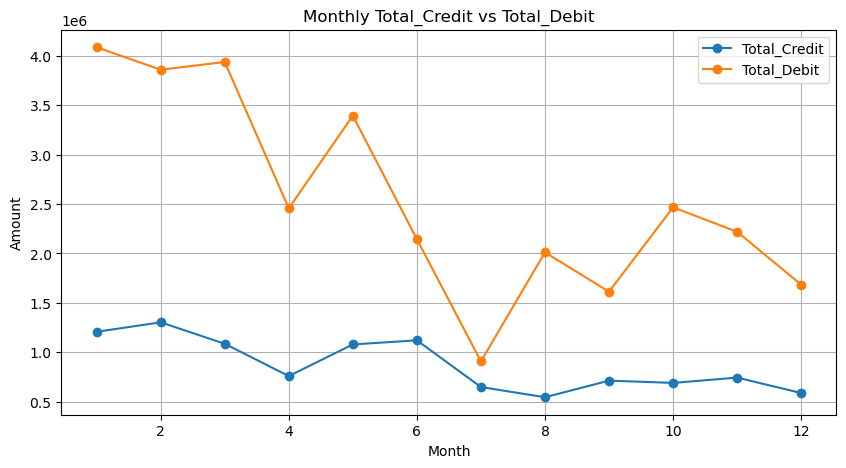

In [ ]:
monthly_summary = df.groupby('Month')[['Total_Credit','Total_Debit']].sum().reset_index()
plt.figure(figsize=(10,5))
plt.plot(monthly_summary['Month'], monthly_summary['Total_Credit'], marker='o')
plt.plot(monthly_summary['Month'], monthly_summary['Total_Debit'], marker='o')
plt.xlabel("Month")
plt.ylabel("Amount")
plt.title("Monthly Total_Credit vs Total_Debit")
plt.legend(['Total_Credit','Total_Debit'])
plt.grid(True)
plt.show()

###    Insights
###    The above line chart of  monthly Total_Credit vs Total_Debit shows
### 1. Total Debit is higher than Total Credit in every month,
### 2. which means money going out is more than money coming in.
### 3. Both credit and debit fluctuate month by month, showing seasonal or usage-based changes.
### 4. Highest debit values appear in the early months, indicating heavier spending during that period.
### 5. There is a sharp drop in debit around mid-year, suggesting reduced spending or fewer transactions.
### 6. Credit values remain relatively stable compared to debit, with smaller ups and downs.
### 7. Towards the end of the year, debit increases again, showing a rise in expenses.
### 8. Overall customers spend more than they receive every month, and spending varies a lot across the year, while income stays more stable.

### Identifying Top & Bottom Performing Accounts based on Net Inflow

In [ ]:
account_summary = df.groupby('AccountID').agg({'Total_Credit': 'sum','Total_Debit': 'sum'}).reset_index()
account_summary['NetInflow'] = account_summary['Total_Credit'] - account_summary['Total_Debit']
account_summary.head()

,AccountID,Total_Credit,Total_Debit,NetInflow
0,ACC10117,142170.20378,57310.763650,84859.440130
1,ACC10996,62580.86356,188158.687390,-125577.823830
2,ACC11062,0.00000,4014.264900,-4014.264900
3,ACC11188,45748.34156,211828.262030,-166079.920470
4,ACC11285,0.00000,96729.609841,-96729.609841


In [ ]:
top_accounts = account_summary.sort_values('NetInflow', ascending=False)
print("\nTop Performing Accounts:")
top_accounts.head()


Top Performing Accounts:


,AccountID,Total_Credit,Total_Debit,NetInflow
92,ACC48501,346856.33960,0.00000,346856.33960
60,ACC33287,390354.42641,201236.66948,189117.75693
168,ACC87006,245497.37832,101488.36862,144009.00970
100,ACC50817,244837.13480,123447.96911,121389.16569
191,ACC99117,167040.52263,45808.22065,121232.30198


In [ ]:
bottom_accounts = account_summary.sort_values('NetInflow')
print("\nBottom Performing Accounts:")
bottom_accounts.head()


Bottom Performing Accounts:


,AccountID,Total_Credit,Total_Debit,NetInflow
107,ACC53466,18181.67381,476775.484990,-458593.811180
49,ACC29396,39888.00143,442832.014120,-402944.012690
118,ACC60432,39623.16730,423334.682580,-383711.515280
48,ACC29356,27344.62435,408228.871838,-380884.247488
55,ACC31539,25819.70053,376944.670070,-351124.969540


### Identifying & flagging accounts as Dormant/Inactive if having gap>= 60 days between 2 consecutive transactions

In [ ]:
df = df.sort_values(['AccountID','TransactionDate'])
df['GapDays'] = df.groupby('AccountID')['TransactionDate'].diff().dt.days
df[["AccountID","TransactionDate","GapDays"]].head()

,AccountID,TransactionDate,GapDays
468,ACC10117,2023-01-30,NaN
25,ACC10117,2023-02-21,22.0
87,ACC10117,2023-06-18,117.0
742,ACC10117,2024-03-14,270.0
384,ACC10996,2023-05-08,NaN


In [ ]:
df['Dormant'] = df['GapDays'].apply(lambda x: "Yes" if x >= 60 else "No")
df[["AccountID","TransactionDate","GapDays","Dormant"]].head()

,AccountID,TransactionDate,GapDays,Dormant
468,ACC10117,2023-01-30,NaN,No
25,ACC10117,2023-02-21,22.0,No
87,ACC10117,2023-06-18,117.0,Yes
742,ACC10117,2024-03-14,270.0,Yes
384,ACC10996,2023-05-08,NaN,No


In [ ]:
inactive_accounts = df[df['Dormant'] == "Yes"]['AccountID'].unique()
len(inactive_accounts)

164

## Above value indicates count of accounts which are Dormant.

In [ ]:
transaction_count = df.groupby("AccountID").size().reset_index(name="Transaction_Frequency")
print("\nTransaction Count Summary:")
transaction_count.head()


Transaction Count Summary:


,AccountID,Transaction_Frequency
0,ACC10117,4
1,ACC10996,5
2,ACC11062,2
3,ACC11188,5
4,ACC11285,3


---

## Task 3: Customer Profile Building

### Used For Loop along with If-Else statement to categorize  Accounts into Activity_Level as High, Medium, Low based on Transaction Frequency

      

### Criteria used for grouping Accounts into Activity_Level based on  Transactional Frequency
Transaction Frequency  Activity Level
 >15                  High
>=10                 Medium
  <10                 Low    

In [ ]:
activity = []

for freq in transaction_count["Transaction_Frequency"]:
    if freq > 15:
        activity.append("High")
    elif freq >= 10:
        activity.append("Medium")
    else:
        activity.append("Low")
transaction_count["Activity_Level"] = activity
print("\nAccounts Transactional Activity Level Summary:")
transaction_count.head()


Accounts Transactional Activity Level Summary:


,AccountID,Transaction_Frequency,Activity_Level
0,ACC10117,4,Low
1,ACC10996,5,Low
2,ACC11062,2,Low
3,ACC11188,5,Low
4,ACC11285,3,Low


## Segmented customers by Average Balance and Transaction Volume
### Created profiles for
#### High Net Inflow Accounts
#### High Frequency Low Balance Accounts
#### Accounts with Negative or Near Zero Balances

In [ ]:
avg_balance = df.groupby("AccountID")["AccountBalance"].mean()
avg_balance = avg_balance.reset_index()
avg_balance.columns = ["AccountID", "Average_Balance"]
print("\nAverage Account Balance Summary:")
avg_balance.head()


Average Account Balance Summary:


,AccountID,Average_Balance
0,ACC10117,70107.007957
1,ACC10996,43568.008084
2,ACC11062,38137.132610
3,ACC11188,69652.151044
4,ACC11285,97401.348560


In [ ]:
transaction_volume = df.groupby("AccountID")["TransactionAmount"].sum()
transaction_volume = transaction_volume.reset_index()
transaction_volume.columns = ["AccountID", "Transaction_Volume"]
transaction_volume.head()

,AccountID,Transaction_Volume
0,ACC10117,199480.967430
1,ACC10996,250739.550950
2,ACC11062,4014.264900
3,ACC11188,257576.603590
4,ACC11285,96729.609841


In [ ]:
customer_profile = transaction_count.merge(avg_balance, on="AccountID")
customer_profile = customer_profile.merge(transaction_volume, on="AccountID")
customer_profile.head()

,AccountID,Transaction_Frequency,Activity_Level,Average_Balance,Transaction_Volume
0,ACC10117,4,Low,70107.007957,199480.967430
1,ACC10996,5,Low,43568.008084,250739.550950
2,ACC11062,2,Low,38137.132610,4014.264900
3,ACC11188,5,Low,69652.151044,257576.603590
4,ACC11285,3,Low,97401.348560,96729.609841


In [ ]:
high_net_inflow = customer_profile[
    (customer_profile["Transaction_Volume"] > customer_profile["Transaction_Volume"].mean()) &
    (customer_profile["Average_Balance"] > customer_profile["Average_Balance"].mean())]
high_net_inflow.head()

,AccountID,Transaction_Frequency,Activity_Level,Average_Balance,Transaction_Volume
7,ACC12334,6,Low,78082.517883,310227.289690
9,ACC15228,5,Low,95389.614144,277925.437360
10,ACC15359,3,Low,118477.129717,243269.680880
13,ACC16241,10,Medium,73521.710375,539612.142850
14,ACC16664,7,Low,86210.297849,283023.049577


In [ ]:
high_freq_low_balance = customer_profile[
    (customer_profile["Activity_Level"] == "High") &
    (customer_profile["Average_Balance"] < customer_profile["Average_Balance"].mean())]
high_freq_low_balance

,AccountID,Transaction_Frequency,Activity_Level,Average_Balance,Transaction_Volume


In [ ]:
negative_balance = customer_profile[customer_profile["Average_Balance"] <= 0]
negative_balance

,AccountID,Transaction_Frequency,Activity_Level,Average_Balance,Transaction_Volume
20,ACC19178,1,Low,-1541.176812,64100.78213


In [ ]:
print("High Net Inflow Accounts:")
high_net_inflow.head()

High Net Inflow Accounts:


,AccountID,Transaction_Frequency,Activity_Level,Average_Balance,Transaction_Volume
7,ACC12334,6,Low,78082.517883,310227.289690
9,ACC15228,5,Low,95389.614144,277925.437360
10,ACC15359,3,Low,118477.129717,243269.680880
13,ACC16241,10,Medium,73521.710375,539612.142850
14,ACC16664,7,Low,86210.297849,283023.049577


In [ ]:
print("\nHigh Frequency Low Balance Accounts")
high_freq_low_balance.head()


High Frequency Low Balance Accounts


,AccountID,Transaction_Frequency,Activity_Level,Average_Balance,Transaction_Volume


### The above empty data indicates there were no High Frequency Low Balance Accounts

In [ ]:
print("\nNegative or Near Zero Balance Accounts")
negative_balance.head()


Negative or Near Zero Balance Accounts


,AccountID,Transaction_Frequency,Activity_Level,Average_Balance,Transaction_Volume
20,ACC19178,1,Low,-1541.176812,64100.78213


### The Above row indicates there was only 1 account having Negative or Near Zero Average Balance

---

## Task 4-Financial Risk Identification

### Used Mean() to find Average Transaction Debit Amount

In [ ]:
debit_types=["Payment","Transfer","Withdrawal"]
average_debit_amount = df[df['TransactionType'].isin(debit_types)]['TransactionAmount'].mean()
print("\nAverage Debit Amount:")
average_debit_amount


Average Debit Amount:


51213.646546823955

### Accounts with Large Debit Amount = Transaction Amount > Average Debit Amount(51213.6465)

In [ ]:
large_debits = df[(df['TransactionType'].isin(debit_types)) &(df['TransactionAmount'] > average_debit_amount)]
print("\nAccounts with Large Debit Amount Summary:")
large_debits[['AccountID', 'TransactionType', 'TransactionAmount']].head()


Accounts with Large Debit Amount Summary:


,AccountID,TransactionType,TransactionAmount
468,ACC10117,Transfer,57310.76365
294,ACC10996,Payment,61653.06253
396,ACC10996,Transfer,61545.77749
574,ACC10996,Withdrawal,52970.34507
8,ACC11188,Withdrawal,67602.35218


### Overdraft Accounts = Accounts having Account Balance < 0

In [ ]:
overdraft_accounts = df[df['AccountBalance'] < 0]
print("\nOverdraft Accounts Summary:")
overdraft_accounts[['AccountID', 'AccountBalance']].head()


Overdraft Accounts Summary:


,AccountID,AccountBalance
122,ACC16241,-19222.713000
618,ACC19178,-1541.176812
607,ACC23736,-9894.658427
174,ACC26973,-8762.711283
400,ACC28154,-97.392834


### Final table showing summary of Large Debit Accounts and Overdraft Accounts

In [ ]:
# Step 1: Defined Debit Transaction Types
debit_types = ['Payment', 'Transfer', 'Withdrawal']

# Step 2: Calculated Average Debit Amount
average_debit_amount = df[df['TransactionType'].isin(debit_types)]['TransactionAmount'].mean()
print("Average Debit Amount:", average_debit_amount)

# Step 3: Created column (Yes / No) using Lambda Function for Large Debits
df['Large_Debit'] = df.apply(lambda x: 'Yes'if (x['TransactionType'] in debit_types and x['TransactionAmount'] > average_debit_amount)else 'No',axis=1)

# Step 4: Created column (Yes / No) using Lambda Function for Overdrafts
df['Overdraft'] = df['AccountBalance'].apply(lambda x: 'Yes' if x < 0 else 'No')

# Step 5: Final table representing summary
final_table = df[['AccountID','TransactionType','TransactionAmount','AccountBalance','Large_Debit','Overdraft']]
final_table.head()

print("\nAccounts with Large Debits and Overdrafts Summary:")
final_table.head()

Average Debit Amount: 51213.646546823955

Accounts with Large Debits and Overdrafts Summary:


,AccountID,TransactionType,TransactionAmount,AccountBalance,Large_Debit,Overdraft
468,ACC10117,Transfer,57310.76365,79464.39475,Yes,No
25,ACC10117,Deposit,67555.28072,89667.83479,No,No
87,ACC10117,Deposit,63248.56067,31961.53479,No,No
742,ACC10117,Deposit,11366.36239,79334.26750,No,No
384,ACC10996,Withdrawal,11989.50230,45731.50391,No,No


### Used Standard Deviation to determine Accounts Balance Volatility
### High Volatility/High Balance Fluctuation = High Instability = High Financial Risk

In [ ]:
balance_volatility = df.groupby('AccountID')['AccountBalance'].std().reset_index()
balance_volatility.columns = ['AccountID', 'BalanceVolatility']
print("\nBalance Volatility Accounts Summary:")
balance_volatility.sort_values('BalanceVolatility', ascending=False).head()


Balance Volatility Accounts Summary:


,AccountID,BalanceVolatility
25,ACC21878,70517.525297
64,ACC34821,61454.350302
5,ACC11837,60694.391957
117,ACC58667,58637.344639
138,ACC71938,56593.572697


In [ ]:
average_volatility = balance_volatility['BalanceVolatility'].mean()
print("\nAverage Volatility:")
average_volatility


Average Volatility:


30568.968153655384

###  Created User Defined Function Classify_Volatility using If-Else statement to determine Volatility Level

### volatility value < 0.75 * average_volatility = Low Level = Low Financial Risk
### volatility value <= 1.25 * average_volatility = Medium Level = Medium Financial Risk
### volatility value  >1.25 * average_volatility = High Level = High Financial Risk

In [ ]:
def classify_volatility(value):
    if value < 0.75 * average_volatility:
        return 'Low'
    elif value <= 1.25 * average_volatility:
        return 'Medium'
    else:
        return 'High'

balance_volatility['Volatility_Level'] = balance_volatility['BalanceVolatility'].apply(classify_volatility)
print("\nAccounts Balance Volatility Summary:")
balance_volatility.head()


Accounts Balance Volatility Summary:


,AccountID,BalanceVolatility,Volatility_Level
0,ACC10117,25886.972758,Medium
1,ACC10996,9434.002316,Low
2,ACC11062,3208.737888,Low
3,ACC11188,35494.660810,Medium
4,ACC11285,55922.732441,High


### Used Z-Score and Lambda Function For Anomaly(Suspicious Transaction) Detection
### Absolute Z-Score > 3 = Anomaly Present indicating Suspicious Transaction. Needs to be investigated Else Safe Transaction

In [ ]:
df['z_score'] = zscore(df['TransactionAmount'])
df['Anomaly'] = df['z_score'].apply(lambda x: 'Yes' if abs(x) > 3 else 'No')
anomaly_table = df[['AccountID', 'TransactionAmount', 'z_score', 'Anomaly']]
print("\nAnomalous Transaction Behavior Summary:")
anomaly_table.head()


Anomalous Transaction Behavior Summary:


,AccountID,TransactionAmount,z_score,Anomaly
468,ACC10117,57310.76365,0.197505,No
25,ACC10117,67555.28072,0.550306,No
87,ACC10117,63248.56067,0.401991,No
742,ACC10117,11366.36239,-1.384729,No
384,ACC10996,11989.50230,-1.363269,No


### Highlighted Suspicious Customers based on Risk Score and Credit Rating using Average Risk Score
### Risk Score > Average Risk Score = Suspicious Customer

In [ ]:
avg_risk = df['RiskScore'].mean()
print("\nAverage Risk:")
avg_risk


Average Risk:


0.47341456047874997

In [ ]:
df['Suspicious_Customer'] = ((df['RiskScore'] > avg_risk) |(df['CreditRating'].isin(['Poor', 'Low']))).map({True: 'Yes', False: 'No'})
suspicious_table = df[['AccountID', 'RiskScore', 'CreditRating', 'Suspicious_Customer']]
print("\nSuspicious Customer Behavior Summary:")
suspicious_table.head()


Suspicious Customer Behavior Summary:


,AccountID,RiskScore,CreditRating,Suspicious_Customer
468,ACC10117,0.354694,354,No
25,ACC10117,0.206170,611,No
87,ACC10117,0.736631,573,Yes
742,ACC10117,0.371513,697,No
384,ACC10996,0.748719,557,Yes


## Task 5: Visualisation of task 4
### Bar graph showing Large Debit Status(Yes/No) vs Number of Transactions

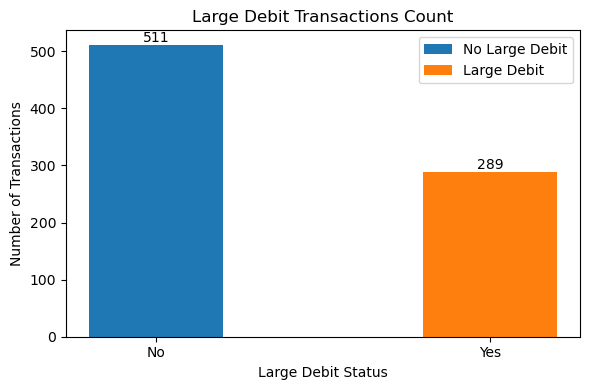

In [ ]:
plt.figure(figsize=(6,4))
bars = plt.bar(['No', 'Yes'],counts.values,color=['#1f77b4', '#ff7f0e'],width=0.4,label=['No Large Debit', 'Large Debit'])
plt.title("Large Debit Transactions Count")
plt.xlabel("Large Debit Status")
plt.ylabel("Number of Transactions")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

###     Insights
#### 1. The bar graph illustrates the distribution of transactions based on Large Debit status (Yes/No).
#### 2. From the analysis, it is observed that the majority of transactions do not involve large debit amounts,
#### 3. While a smaller proportion of transactions are classified as large debits.
#### 4. This indicates that customers generally perform regular-sized transactions, and large debit transactions occur less frequently.


### Pie Chart showing Proportion of Overdraft vs Non-Overdraft Accounts

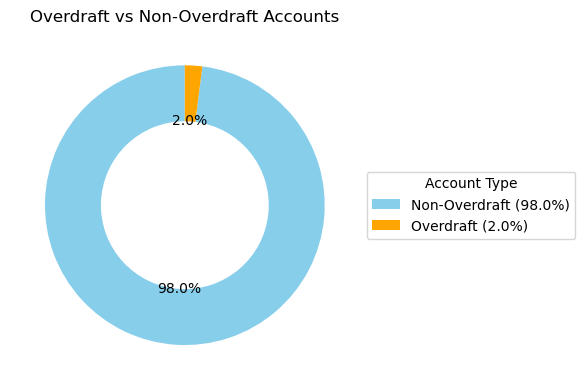

In [ ]:
plt.figure(figsize=(6,4))
plt.pie(overdraft_counts.reindex(['No', 'Yes']),autopct='%1.1f%%',startangle=90,colors=['skyblue', 'orange'],wedgeprops={'width': 0.4})
plt.legend(labels,title="Account Type",loc="center left",bbox_to_anchor=(1, 0.5))
plt.title("Overdraft vs Non-Overdraft Accounts")
plt.tight_layout()
plt.show()

###     Insights
#### 1. The above pie chart represents proportion of overdraft vs non-overdraft accounts categories.
#### 2. It shows overdraft accounts contributed  around 2% of total accounts whereas non overdraft account contributed around 98%.
#### 3. This indicates majority of people maintain sufficient balance in their account.
#### 4. From risk point of view it indicates less chances of risk and losses due to low proportion of overdraft accounts


### Distribution of Account Balance Volatility using Histogram

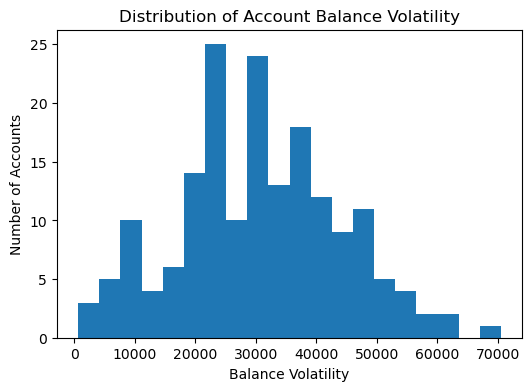

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(balance_volatility['BalanceVolatility'], bins=20)
plt.title("Distribution of Account Balance Volatility")
plt.xlabel("Balance Volatility")
plt.ylabel("Number of Accounts")
plt.show()

###     Insights
#### 1. Most accounts show moderate balance volatility, meaning their balances change but not drastically.
#### 2. A large number of accounts are clustered in the middle range, indicating stable and regular transaction behavior.
#### 3. Only a few accounts have very high balance volatility, which means their balances fluctuate a lot.
#### 4. Very low volatility accounts are also fewer, suggesting most customers actively use their accounts.
#### 5. Overall, the distribution shows that extreme balance changes are uncommon, and most customers maintain reasonably stable account balances.

### Bar graph showing Accounts by Volatility Level

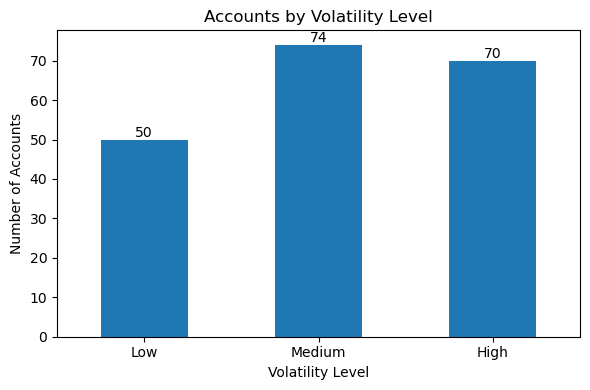

In [ ]:
plt.figure(figsize=(6,4))
ax = volatility_level_counts.plot(kind='bar')
plt.title("Accounts by Volatility Level")
plt.xlabel("Volatility Level")
plt.ylabel("Number of Accounts")
plt.xticks(rotation=0)
for i, value in enumerate(volatility_level_counts.values):
    ax.text(i, value, value, ha='center', va='bottom')
plt.tight_layout()
plt.show()

###     Insights
#### 1. The above bar graph shows, most accounts around 74 fall under Medium volatility.
#### 2. A large number of accounts around 70 also show High volatility, meaning their balances change a lot.
#### 3. Low volatility accounts are fewer around 50, indicating fewer customers keep very stable balances.
#### 4. Overall, most customers have moderate to high changes in their account balances.

### Scatter plot showing z-score based Anomaly Detection for Transaction Amount

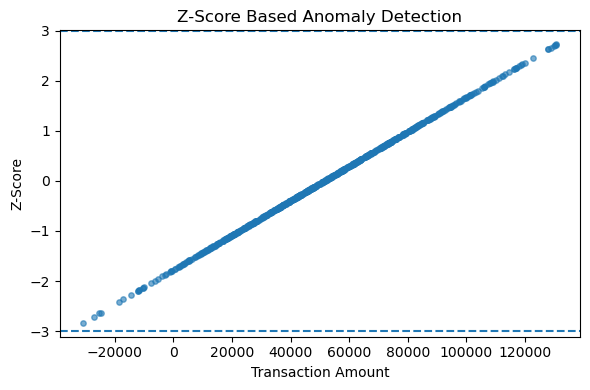

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df['TransactionAmount'], df['z_score'], s=15, alpha=0.6)
plt.axhline(3, linestyle='--')
plt.axhline(-3, linestyle='--')
plt.title("Z-Score Based Anomaly Detection")
plt.xlabel("Transaction Amount")
plt.ylabel("Z-Score")
plt.tight_layout()
plt.show()

###     Insights
#### 1. Each dot in above scatter plot represents a transaction amount and its z-score (how far it is from the average).
#### 2. Most transactions lie between z-scores −3 and +3, which means they are normal transactions.
#### 3. Only very few points are close to the ±3 lines, indicating potentially unusual or extreme transactions.
#### 4. As the transaction amount increases, the z-score also increases, showing a clear and consistent pattern.
#### 5. Overall it indicates most transactions are normal, and only a small number of transactions look unusual and may need further checking.



### Risk Score Distribution Using Histogram

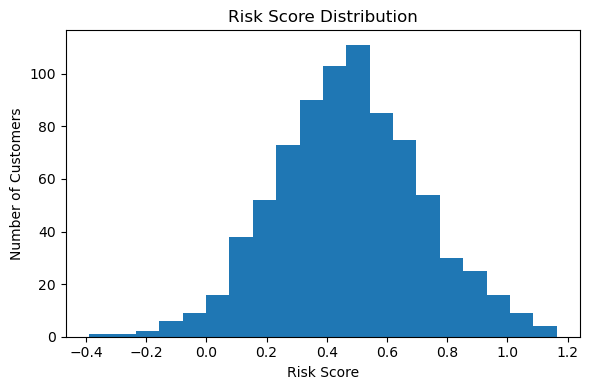

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df['RiskScore'], bins=20)
plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

###     Insights
#### 1. From above histogram it is observed that most customers have medium risk scores, concentrated around the center of the graph.
#### 2. Very few customers fall at extremely low or extremely high risk scores.
#### 3. The distribution looks balanced and bell-shaped, which means risk is spread normally across customers.
#### 4. High-risk customers exist but form a small portion of the total population.
#### 5. Low-risk customers also exist, indicating a group with very safe financial behavior.

### Bar graph showing Suspicious Customer vs Normal Customer Category

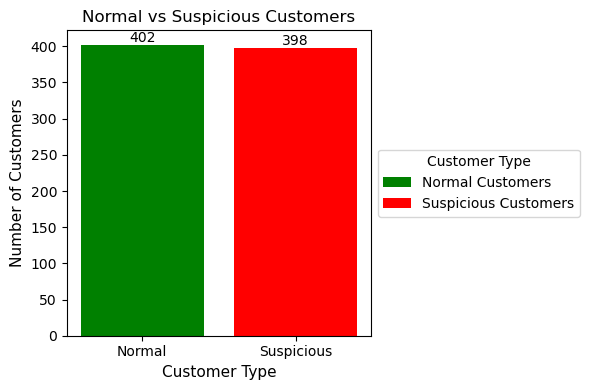

In [ ]:
categories = ["Normal", "Suspicious"]
values = [402, 398]
colors = ["green", "red"]
plt.figure(figsize=(6, 4))
bars = plt.bar(categories, values, color=colors)
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        bar.get_height(),
        ha="center",
        va="bottom")
plt.xlabel("Customer Type", fontsize=11)
plt.ylabel("Number of Customers", fontsize=11)
plt.title("Normal vs Suspicious Customers", fontsize=12)
legend_elements = [Patch(facecolor="green", label="Normal Customers"),Patch(facecolor="red", label="Suspicious Customers")]
plt.legend(handles=legend_elements,title="Customer Type",loc="center left",bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

###     Insights
#### 1. Above bar graph illustrates that the number of Normal customers and Suspicious customers is almost the same.
#### 2. This shows that a significant portion of customers are flagged as suspicious.
#### 3. The difference between the two groups is very small, indicating suspicious activity is not rare in the dataset.
#### 4. The system is actively identifying risky behavior, not just a few extreme cases.
#### 5. Nearly half of the customers show suspicious behavior, so monitoring and fraud detection are very important.

## Task 6: Hypothesis Testing

## Objective
### To check whether high-volume transaction accounts have higher average balances than low-volume transaction accounts
### Method used- Z-Test
### Consider Null Hypothesis(H0) and Alternative Hypothesis(H1) for above statement as follows
### Null Hypothesis(H0)- High-volume and low-volume transaction accounts have nearly same average balance.
### Alternative Hypothesis(H1)-High-volume transaction accounts have a higher average balance than low-volume accounts.

In [ ]:
txn_count = df.groupby("AccountID").size().reset_index(name="TransactionCount")
txn_count.head()

,AccountID,TransactionCount
0,ACC10117,4
1,ACC10996,5
2,ACC11062,2
3,ACC11188,5
4,ACC11285,3


In [ ]:
avg_balance = df.groupby("AccountID")["AccountBalance"].mean().reset_index()
avg_balance.head()

,AccountID,AccountBalance
0,ACC10117,70107.007957
1,ACC10996,43568.008084
2,ACC11062,38137.132610
3,ACC11188,69652.151044
4,ACC11285,97401.348560


In [ ]:
data = pd.merge(txn_count, avg_balance, on="AccountID")
data.head()

,AccountID,TransactionCount,AccountBalance
0,ACC10117,4,70107.007957
1,ACC10996,5,43568.008084
2,ACC11062,2,38137.132610
3,ACC11188,5,69652.151044
4,ACC11285,3,97401.348560


### Used Median to segment High Volume and Low Volume Transaction Accounts based on Average Account Balance
### Criteria used
### Accounts with Average Balance above median → High-Volume Transaction
### Accounts with Average Balance below or equal to median → Low-Volume Transaction

In [ ]:
median_txn = data["TransactionCount"].median()
high_volume = data[data["TransactionCount"] > median_txn]["AccountBalance"]
low_volume = data[data["TransactionCount"] <= median_txn]["AccountBalance"]
len(high_volume), len(low_volume)

(73, 121)

In [ ]:
z_value, p_value = ztest(high_volume, low_volume, alternative="larger")
z_value, p_value

(0.2834217155894371, 0.38842679195699825)

In [ ]:
print("\nZ-Test Summary:")
print("Average Balance (High Volume):", round(high_volume.mean(), 2))
print("Average Balance (Low Volume):", round(low_volume.mean(), 2))
print("Z Value:", round(z_value, 3))
print("P Value:", round(p_value, 3))


Z-Test Summary:
Average Balance (High Volume): 72512.19
Average Balance (Low Volume): 71683.28
Z Value: 0.283
P Value: 0.388


### Used If-Else statement using P-Value at alpha=0.05 to determine whether to Accept or to Reject Null Hypothesis
### P-Value obtained using Z-Test: 0.388
### Since P-Value > 0.05
###       ie.0.388 > 0.05
### Failed to Reject Null Hypothesis/Accepted Null Hypothesis

In [ ]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("High-Volume Transaction Accounts have Statistically Higher Average Balances than Low-Volume Accounts.")
else:
    print("Failed to Reject Null Hypothesis")
    print("High-Volume Transaction Accounts do not have Statistically Higher Average Balances than Low-Volume Accounts.")
    print("High-Volume and Low-Volume Transaction Accounts have nearly same Average Account Balance.")

Failed to Reject Null Hypothesis
High-Volume Transaction Accounts do not have Statistically Higher Average Balances than Low-Volume Accounts.
High-Volume and Low-Volume Transaction Accounts have nearly same Average Account Balance.


##      ## Recommendations
#### 1. Accounts having frequent Large debit transactions need to be closely monitored.
#### 2. Setting early real time alerts or notification for Low Account Balance, Overdrafts, Frequent Large Debit Transactions
#### 3. thus identifying fraud or suspicious activity in early stage, minimizing financial loss to bank as well as customers.
#### 4. Thus building customers trust and engagement with the bank.
#### 5. Accounts with high balance fluctuation should be tracked and reviewed.
#### 6. Accounts with high risk score should be carefully monitored as they can lead to fraud, financial risk.
#### 7. Educating high spending people about importance of saving.
#### 8. Transactions with Unusual or suspicious behavior should be flagged and investigated.
#### 9. Combination of multiple risk indicators including risk score, large debit transactions, z-score and overdrafts could minimize financial risk
#### 10. Thus supporting better financial decision making.

### Watch Recording by clicking on the link given below


### https://www.loom.com/share/3bd1239a663044c686efb20aa7f92741